<a href="https://colab.research.google.com/github/igorpedrozo27/MVP_Machine_Learning/blob/main/Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Igor de Almeida Leite Pedrozo

**Matrícula:** 4052025002180

**Data:** 07/2026

**Dataset:** [Base_Onduladeira](https://https://github.com/igorpedrozo27/MVP_Machine_Learning/tree/main/data)

**Tipo de problema:** Regressão

## Descrição do Problema

**Contexto do Problema**

O processo de fabricação de chapas de papelão ondulado é instável e sujeito a interrupções mecânicas, variações de matéria-prima e oscilações na demanda do mix de produção.
>Atualmente, a planta opera sem uma ferramenta preditiva que permita antecipar a magnitude das perdas com base nas condições operacionais planejadas para o turno.

**Objetivo da Solução**

O modelo desenvolvido visa realizar a **previsão da quantidade de refugo (em Kg)** gerada diariamente na onduladeira.
>Esta previsão apoia a tomada de decisão do Planejamento e Controle da Produção (PCP), permitindo que a gestão identifique cenários de alto risco de desperdício antes do início da operação, possibilitando ajustes proativos no sequenciamento de pedidos ou na alocação de recursos para mitigar perdas.

**Usuários e Interessados**


Gestores de produção, a equipe de PCP (Planejamento e Controle da Produção) e a controladoria industrial.
>O modelo serve como uma ferramenta de suporte ao planejamento, fornecendo visibilidade antecipada sobre a eficiência esperada do dia.

**Relevância do Problema**

Este problema é central para a competitividade da empresa por três pilares:
1. **Redução de Custos:** O refugo representa perda direta de matéria-prima e custo industrial absorvido; qualquer redução marginal impacta diretamente a margem de contribuição.
2. **Eficiência Operacional:** Identificar padrões que geram desperdício (como a fragmentação excessiva de setups) permite otimizar o *mix* de produção sem comprometer a entrega.
3. **Maturidade Analítica:** Como a fábrica está em estágio de digitalização, este modelo estabelece um novo paradigma de gestão baseada em dados, substituindo a intuição operacional por previsões quantitativas e auditáveis.

## Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever o volume diário de refugo da onduladeira (em Kg) a partir de variáveis operacionais de produção, setup e sazonalidade gerencial, comparando uma abordagem baseline com modelos candidatos e discutindo suas limitações.

### Tipo de Problema

* **Tipo escolhido:**
Regressão (com abordagem de séries temporais).

* **Justificativa:**
O objetivo central é prever uma grandeza física contínua — o peso do refugo em quilogramas (Kg). Tratando-se de uma variável numérica de escala, a tarefa enquadra-se tecnicamente como um problema de Regressão. Embora os dados possuam uma natureza temporal, a modelagem foi estruturada como uma previsão tabular (estática por dia), onde as variáveis independentes de cada registro carregam o contexto necessário para a predição daquele dia específico.
>Adicionalmente, embora o problema guarde relação com Séries Temporais, a modelagem foi tratada sob a ótica de *Machine Learning* tabular para capturar as correlações complexas entre variáveis operacionais simultâneas (o *estado da máquina* naquele dia), mitigando o risco de sobreajuste por dependência temporal excessiva em um cenário de *Small Data*. A validação cruzada foi aplicada para garantir que a performance seja representativa em diferentes janelas temporais da operação. O intuito é testar outras soluções conforme a base aumentar.

## Premissas, Hipóteses e Critérios de Sucesso

**Hipóteses Iniciais**
* **Hipótese 1 (Efeito da Instabilidade):** A frequência de ciclos de parada ("liga-desliga") na onduladeira é um preditor de refugo mais significativo do que o tempo total de paradas, devido ao estresse mecânico e térmico gerado em cada reinício.
* **Hipótese 2 (Sazonalidade Gerencial):** A pressão por metas de faturamento nas semanas finais do mês altera o sequenciamento produtivo (aumento de setups), resultando em um volume de refugo estatisticamente superior ao das primeiras semanas.

**Critérios de Sucesso**
* **Métrica Principal:** O **MAE (Erro Médio Absoluto)**, medido em quilogramas (Kg). A escolha desta métrica é estratégica, pois quantifica o desvio médio na mesma unidade utilizada pela contabilidade de custos industriais, facilitando a interpretação pelos gestores da planta.
* **Resultado Mínimo Esperado:** O modelo deve apresentar uma redução de pelo menos 5% no MAE em relação ao modelo *baseline* (Regressão Linear), demonstrando valor incremental na capacidade de prever perdas.

* **Restrições Práticas:**
    * **Interpretabilidade:** O modelo deve permitir a extração de *feature importance*, garantindo que a gestão compreenda quais variáveis operacionais estão impulsionando o refugo previsto.
    
    * **Simplicidade e Manutenibilidade:** Dada a estrutura de *Small Data* da fábrica, o modelo deve evitar complexidade algorítmica excessiva, priorizando algoritmos que possuam baixo custo computacional para permitir execuções diárias rápidas em ambientes de infraestrutura de TI em digitalização.

In [1]:
!pip install xgboost lightgbm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.linear_model import LinearRegression # Modelo baseline
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error


import warnings
warnings.filterwarnings('ignore') # Limpa avisos de depreciação durante o treino

# Fixando a semente (seed) para garantir reprodutibilidade
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Configuração visual padrão para os gráficos de análise exploratória
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.max_columns', None) # Garante que o Pandas mostre todas as colunas

print("Ambiente configurado e bibliotecas importadas com sucesso!")

Ambiente configurado e bibliotecas importadas com sucesso!


## CARGA E INSPEÇÃO INICIAL DOS DADOS

## Apresentação e Contextualização dos Dados

Esta seção descreve a base de dados utilizada para o treinamento e validação dos modelos preditivos de refugo industrial.

* **Fonte dos Dados:** A base é composta pela integração de dados extraídos diretamente do sistema de apontamento de paradas da linha de produção (onduladeira) de uma indústria do papelão ondulado. Em processo de digitalização, os dados históricos da fábrica são limitados (Small Data), mas de alta confiança.
  * O *dataset* **inicial** conta com:
    * 4 tabelas fato:
      * fact_Paradas_Maquina.csv
      * fact_Qtde_Produzida.csv
      * fact_Refugo_Refile.csv
      * fact_Tempo_Turno.csv
    * 2 tabelas dimensão:
      * dim_Codigo_Causas_Parada.csv
      * dim_Calendario.csv
>
* **Volume de Dados:** O *dataset* **final** para modelagem obtido após preparação dos dados e feature engineering compreende **128 registros diários** (dias úteis de operação) e **20 atributos** (variáveis operacionais, de tempo e de mix de produção).

* **Variável-Alvo:** O modelo tem como objetivo predizer o `REFUGO_ONDULADEIRA`, medido em quilogramas (Kg).

* **Descrição das Principais Variáveis:**
    * **Variáveis de Escala:** `Volume_Kg` (output total produzido no dia).
    * **Variáveis de Instabilidade:** `Qtd_Total_Paradas` (frequência de ciclos "liga-desliga") e `Total_Minutos_Parados`.
    * **Variáveis de Mix/Complexidade:** `Qtd_Setups_Rodados`, `Mix_Ondas` e `Mix_Papeis`.
    * **Variáveis Temporais:** `Semana_Mes` (indicador de sazonalidade e pressão gerencial de fechamento).

* **Critérios de Seleção:** O presente conjunto de dados reflete o estágio inicial do processo de digitalização da planta industrial. Ele consolida registros operacionais diários de um ambiente industrial real e visa o futuro desenvolvimento para solucionar problemas reais da fábrica.

* **Limitações do Dataset:**
    * **Volumetria (Small Data):** A limitação do histórico disponível decorre da implementação recente do sistema de apontamento digital.

    * **Ausência de Telemetria IoT:** O modelo baseia-se em apontamentos manuais e sistêmicos; variáveis físicas de alta frequência (como temperatura exata das chapas ou velocidade instantânea da onduladeira) não estão presentes, o que limita o modelo à correlação de eventos macro, não de variáveis de engenharia contínua.

In [2]:
# URL base do repositório no GitHub (versão raw)
URL_BASE = "https://raw.githubusercontent.com/igorpedrozo27/MVP_Machine_Learning/refs/heads/main/data/"

# Definição das URLs completas
url_producao = f"{URL_BASE}fact_Qtde_Produzida.csv"
url_paradas = f"{URL_BASE}fact_Paradas_Maquina.csv"
url_refugo = f"{URL_BASE}fact_Refugo_Refile.csv"
url_tempo_turno = f"{URL_BASE}fact_Tempo_Turno.csv"
url_causas = f"{URL_BASE}dim_Codigo_Causas_Parada.csv"
url_calendario = f"{URL_BASE}dim_Calendario.csv"

try:
    df_producao = pd.read_csv(url_producao, sep=',', encoding='utf-8')
    df_paradas = pd.read_csv(url_paradas, sep=',', encoding='utf-8')
    df_refugo = pd.read_csv(url_refugo, sep=',', encoding='utf-8')
    df_tempo = pd.read_csv(url_tempo_turno, sep=',', encoding='utf-8')
    df_causas = pd.read_csv(url_causas, sep=',', encoding='utf-8')
    df_calendario = pd.read_csv(url_calendario, sep=',', encoding='utf-8')

    print("Todos os arquivos foram carregados com sucesso diretamente do GitHub!\n")

    # Exibindo o tamanho das bases (Linhas, Colunas)
    print("DIMENSÕES:\n")
    print(f"Dimensões de Produção: {df_producao.shape}\n")
    print(f"Dimensões de Paradas:  {df_paradas.shape}\n")
    print(f"Dimensões de Refugo:   {df_refugo.shape}\n")
    print(f"Dimensões de Tempo de Turno:   {df_tempo.shape}\n")
    print(f"Dimensões de Causas de Parada:   {df_causas.shape}\n")
    print(f"Dimensões de Calendário:   {df_calendario.shape}\n")

    # Listando as colunas disponíveis para mapeamento
    print("COLUNAS DISPONÍVEIS:\n")
    print(f"-> Produção: {df_producao.columns.tolist()}\n")
    print(f"-> Paradas:  {df_paradas.columns.tolist()}\n")
    print(f"-> Refugo:   {df_refugo.columns.tolist()}\n")
    print(f"-> Tempo:    {df_tempo.columns.tolist()}\n")
    print(f"-> Causas:   {df_causas.columns.tolist()}\n")
    print(f"-> Calendário:   {df_calendario.columns.tolist()}\n")

except Exception as e:
    print("Erro: Não foi possível carregar um ou mais arquivos do GitHub.")
    print("Verifique se o repositório está como 'Público', se os nomes dos arquivos estão corretos ou sua conexão.")
    print(f"Detalhe do erro: {e}")


Todos os arquivos foram carregados com sucesso diretamente do GitHub!

DIMENSÕES:

Dimensões de Produção: (2420, 8)

Dimensões de Paradas:  (4294, 10)

Dimensões de Refugo:   (147, 3)

Dimensões de Tempo de Turno:   (253, 9)

Dimensões de Causas de Parada:   (34, 3)

Dimensões de Calendário:   (177, 8)

COLUNAS DISPONÍVEIS:

-> Produção: ['Data', 'Formato', 'Kg_Produzidos', 'Metro_Linear', 'Metro_Quadrado', 'Tipo_Onda', 'Tipo_Papel', 'Turno']

-> Paradas:  ['CÓD.', 'Data', 'Fim', 'Inicio', 'InicioDT', 'FimDT', 'OBSERVAÇÃO', 'Tempo de Parada (hrs)', 'Tempo de Parada (min)', 'Turno']

-> Refugo:   ['Data', 'PRODUZIDO_Onduladeira', 'REFUGO_ONDULADEIRA']

-> Tempo:    ['Data', 'Data Fim', 'Fim', 'Fim DateTime', 'Inicio', 'Inicio DateTime', 'Tempo de Turno (hrs)', 'Tempo de Turno (min)', 'Turno']

-> Causas:   ['Causa de Parada', 'Classificacao_de_Parada', 'Código']

-> Calendário:   ['Ano', 'Data', 'Início do Mês', 'Mês', 'Nome do Mês', 'Nome Semana do Mes', 'Semana do Ano', 'Semana do Mês

In [3]:
print("\n")
print("PRODUÇÃO")
print("\n")
df_producao.info()
print("\n")
print(60*"=")
print("\n")
print("PARADAS")
print("\n")
df_paradas.info()
print("\n")
print(60*"=")
print("\n")
print("REFUGO")
print("\n")
df_refugo.info()
print("\n")
print(60*"=")
print("\n")
print("TEMPO")
print("\n")
df_tempo.info()
print("\n")
print(60*"=")
print("\n")
print("CAUSAS")
print("\n")
df_causas.info()
print("\n")
print(60*"=")
print("\n")
print("CALENDÁRIO")
print("\n")
df_calendario.info()



PRODUÇÃO


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2420 entries, 0 to 2419
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Data            2419 non-null   object 
 1   Formato         2419 non-null   float64
 2   Kg_Produzidos   2419 non-null   float64
 3   Metro_Linear    2419 non-null   float64
 4   Metro_Quadrado  2419 non-null   float64
 5   Tipo_Onda       2419 non-null   object 
 6   Tipo_Papel      2419 non-null   object 
 7   Turno           2419 non-null   object 
dtypes: float64(4), object(4)
memory usage: 151.4+ KB




PARADAS


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4294 entries, 0 to 4293
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   CÓD.                   4294 non-null   int64 
 1   Data                   4294 non-null   object
 2   Fim                    4294 non-null   object
 

In [4]:
display(df_producao.head())

,Data,Formato,Kg_Produzidos,Metro_Linear,Metro_Quadrado,Tipo_Onda,Tipo_Papel,Turno
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-01-05 00:00:00,2040.0,903.0,893.0,1821.0,B,KK,TARDE
2,2026-01-05 00:00:00,2040.0,3715.0,5174.0,10554.0,B,KC,TARDE
3,2026-01-05 00:00:00,2040.0,7499.0,9623.0,19630.0,B,KK,TARDE
4,2026-01-05 00:00:00,2200.0,4935.0,5679.0,12493.0,C,KC,MANHA


In [5]:
display(df_paradas.head())

,CÓD.,Data,Fim,Inicio,InicioDT,FimDT,OBSERVAÇÃO,Tempo de Parada (hrs),Tempo de Parada (min),Turno
0,1,2026-01-06 00:00:00,1899-12-30 22:00:00,1899-12-30 21:00:00,2026-01-06 21:00:00,2026-01-06 22:00:00,Janta Geral,"1,00",60,TARDE
1,1,2026-01-07 00:00:00,1899-12-30 22:00:00,1899-12-30 21:00:00,2026-01-07 21:00:00,2026-01-07 22:00:00,Jantar geral,"1,00",60,TARDE
2,1,2026-01-08 00:00:00,1899-12-30 22:30:00,1899-12-30 21:00:00,2026-01-08 21:00:00,2026-01-08 22:30:00,Janta Geral,"1,50",90,TARDE
3,1,2026-01-09 00:00:00,1899-12-30 22:00:00,1899-12-30 21:00:00,2026-01-09 21:00:00,2026-01-09 22:00:00,Jantar geral,"1,00",60,TARDE
4,1,2026-01-12 00:00:00,1899-12-30 21:00:00,1899-12-30 20:30:00,2026-01-12 20:30:00,2026-01-12 21:00:00,Janta Geral,"0,50",30,TARDE


In [6]:
display(df_refugo.head())

,Data,PRODUZIDO_Onduladeira,REFUGO_ONDULADEIRA
0,2026-01-05 00:00:00,60273,4091
1,2026-01-06 00:00:00,99871,6492
2,2026-01-07 00:00:00,105876,5411
3,2026-01-08 00:00:00,107478,3055
4,2026-01-09 00:00:00,85980,4411


In [7]:
display(df_tempo.head())

,Data,Data Fim,Fim,Fim DateTime,Inicio,Inicio DateTime,Tempo de Turno (hrs),Tempo de Turno (min),Turno
0,2026-01-05 00:00:00,2026-01-05 00:00:00,1899-12-30 14:30:00,2026-01-05 14:30:00,1899-12-30 06:00:00,2026-01-05 06:00:00,8.5,510,MANHA
1,2026-01-05 00:00:00,2026-01-05 00:00:00,1899-12-30 23:30:00,2026-01-05 23:30:00,1899-12-30 14:30:00,2026-01-05 14:30:00,9.0,540,TARDE
2,2026-01-06 00:00:00,2026-01-06 00:00:00,1899-12-30 18:00:00,2026-01-06 18:00:00,1899-12-30 06:00:00,2026-01-06 06:00:00,12.0,720,MANHA
3,2026-01-06 00:00:00,2026-01-07 00:00:00,1899-12-30 06:00:00,2026-01-07 06:00:00,1899-12-30 18:00:00,2026-01-06 18:00:00,12.0,720,TARDE
4,2026-01-07 00:00:00,2026-01-07 00:00:00,1899-12-30 18:00:00,2026-01-07 18:00:00,1899-12-30 06:00:00,2026-01-07 06:00:00,12.0,720,MANHA


In [8]:
display(df_causas.head())

,Causa de Parada,Classificacao_de_Parada,Código
0,Acumulo de Chapas,Microparada,32
1,Aferimento,Parada Planejada,29
2,Defeito Elétrico,Parada Não Planejada,4
3,Defeito Mecânico,Parada Não Planejada,3
4,Erro de Programação,Parada Não Planejada,27


In [9]:
display(df_calendario.head())

,Ano,Data,Início do Mês,Mês,Nome do Mês,Nome Semana do Mes,Semana do Ano,Semana do Mês
0,2026,2026-01-05 00:00:00,2026-01-01 00:00:00,1,janeiro,1ª Semana,2,1
1,2026,2026-01-06 00:00:00,2026-01-01 00:00:00,1,janeiro,1ª Semana,2,1
2,2026,2026-01-07 00:00:00,2026-01-01 00:00:00,1,janeiro,1ª Semana,2,1
3,2026,2026-01-08 00:00:00,2026-01-01 00:00:00,1,janeiro,2ª Semana,2,2
4,2026,2026-01-09 00:00:00,2026-01-01 00:00:00,1,janeiro,2ª Semana,2,2


### Retirando o valor nulo existente no dataframe de produção.

In [10]:
df_producao = df_producao.dropna(how='all')
df_producao.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2419 entries, 1 to 2419
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Data            2419 non-null   object 
 1   Formato         2419 non-null   float64
 2   Kg_Produzidos   2419 non-null   float64
 3   Metro_Linear    2419 non-null   float64
 4   Metro_Quadrado  2419 non-null   float64
 5   Tipo_Onda       2419 non-null   object 
 6   Tipo_Papel      2419 non-null   object 
 7   Turno           2419 non-null   object 
dtypes: float64(4), object(4)
memory usage: 170.1+ KB


## PREPARAÇÃO DE DADOS E FEATURE ENGINEERING

In [11]:
# Padronização Temporal

df_producao['Data'] = pd.to_datetime(df_producao['Data'])
df_paradas['Data'] = pd.to_datetime(df_paradas['Data'])
df_refugo['Data'] = pd.to_datetime(df_refugo['Data'])
df_tempo['Data'] = pd.to_datetime(df_tempo['Data'])
df_calendario['Data'] = pd.to_datetime(df_calendario['Data']) # Padronizando o calendário

# Enriquecimento e Pivotamento das PARADAS

df_paradas_enriquecida = pd.merge(df_paradas, df_causas, left_on='CÓD.', right_on='Código', how='left')

df_paradas_diario = df_paradas_enriquecida.pivot_table(
    index='Data',
    columns='Classificacao_de_Parada',
    values='Tempo de Parada (min)',
    aggfunc='sum',
    fill_value=0
).reset_index()

df_paradas_diario.columns = ['Data'] + [f"Min_{str(c).replace(' ', '_').replace('ã', 'a')}" for c in df_paradas_diario.columns[1:]]

df_qtd_eventos = df_paradas.groupby('Data').size().reset_index(name='Qtd_Total_Paradas')
df_paradas_diario = pd.merge(df_paradas_diario, df_qtd_eventos, on='Data', how='outer')

# Agrupamento da PRODUÇÃO

df_producao_diario = df_producao.groupby('Data').agg(
    Volume_Metro_Linear=('Metro_Linear', 'sum'),
    Volume_Kg=('Kg_Produzidos', 'sum'),
    Qtd_Setups_Rodados=('Formato', 'count'),
    Mix_Ondas=('Tipo_Onda', 'nunique'),
    Mix_Papeis=('Tipo_Papel', 'nunique')
).reset_index()

# Agrupamento do TEMPO DE TURNO

df_tempo_diario = df_tempo.groupby('Data').agg(
    Minutos_Disponiveis_Dia=('Tempo de Turno (min)', 'sum')
).reset_index()

# MERGE DA TABELA MESTRE

df_master = pd.merge(df_refugo, df_producao_diario, on='Data', how='left')
df_master = pd.merge(df_master, df_paradas_diario, on='Data', how='left')
df_master = pd.merge(df_master, df_tempo_diario, on='Data', how='left')

# Inserindo a dimensão Calendário (Trazendo Semana do Ano e Semana do Mês)
# Selecionei apenas as colunas úteis para não poluir o dataset com textos desnecessários

df_master = pd.merge(df_master, df_calendario[['Data', 'Semana do Ano', 'Semana do Mês']], on='Data', how='left')
df_master = df_master.rename(columns={'Semana do Ano': 'Semana_Ano', 'Semana do Mês': 'Semana_Mes'})

# Limpeza e Variáveis de Eficiência

colunas_paradas = [c for c in df_master.columns if 'Min_' in c or 'Qtd_' in c]
df_master[colunas_paradas] = df_master[colunas_paradas].fillna(0)
df_master = df_master.dropna()

# Filtrando os dias sem produção

df_master = df_master[df_master['PRODUZIDO_Onduladeira'] > 0]

# Calculando Tempo Líquido e Percentuais de Eficiência

todas_paradas_cols = [c for c in df_master.columns if c.startswith('Min_')]
df_master['Total_Minutos_Parados'] = df_master[todas_paradas_cols].sum(axis=1)

df_master['Tempo_Liquido_Producao_min'] = df_master['Minutos_Disponiveis_Dia'] - df_master['Total_Minutos_Parados']
df_master['Perc_Tempo_Parado'] = (df_master['Total_Minutos_Parados'] / df_master['Minutos_Disponiveis_Dia']) * 100

print("\n")
print(f"Dimensões finais: {df_master.shape[0]} linhas (dias) e {df_master.shape[1]} colunas (features).")

print("\n")

display(df_master.head())
print("\n")
df_master.info()
print("\n")



Dimensões finais: 128 linhas (dias) e 20 colunas (features).




,Data,PRODUZIDO_Onduladeira,REFUGO_ONDULADEIRA,Volume_Metro_Linear,Volume_Kg,Qtd_Setups_Rodados,Mix_Ondas,Mix_Papeis,Min_Microparada,Min_Outros,Min_Parada_Nao_Planejada,Min_Parada_Planejada,Min_Setup,Qtd_Total_Paradas,Minutos_Disponiveis_Dia,Semana_Ano,Semana_Mes,Total_Minutos_Parados,Tempo_Liquido_Producao_min,Perc_Tempo_Parado
0,2026-01-05,60273,4091,62317.0,60273.0,12.0,3.0,6.0,0.0,3.0,236.0,0.0,91.0,26.0,1050.0,2,1,330.0,720.0,31.428571
1,2026-01-06,99871,6492,86813.0,99871.0,30.0,3.0,6.0,4.0,10.0,171.0,60.0,160.0,43.0,1440.0,2,1,405.0,1035.0,28.125000
2,2026-01-07,105876,5411,110778.0,105876.0,18.0,2.0,7.0,0.0,0.0,237.0,60.0,69.0,38.0,1440.0,2,1,366.0,1074.0,25.416667
3,2026-01-08,107478,3055,105839.0,107438.0,22.0,3.0,8.0,0.0,20.0,121.0,90.0,130.0,39.0,1440.0,2,2,361.0,1079.0,25.069444
4,2026-01-09,85980,4411,80041.0,85980.0,19.0,3.0,5.0,0.0,7.0,81.0,60.0,78.0,26.0,1065.0,2,2,226.0,839.0,21.220657




<class 'pandas.core.frame.DataFrame'>
Index: 128 entries, 0 to 146
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Data                        128 non-null    datetime64[ns]
 1   PRODUZIDO_Onduladeira       128 non-null    int64         
 2   REFUGO_ONDULADEIRA          128 non-null    int64         
 3   Volume_Metro_Linear         128 non-null    float64       
 4   Volume_Kg                   128 non-null    float64       
 5   Qtd_Setups_Rodados          128 non-null    float64       
 6   Mix_Ondas                   128 non-null    float64       
 7   Mix_Papeis                  128 non-null    float64       
 8   Min_Microparada             128 non-null    float64       
 9   Min_Outros                  128 non-null    float64       
 10  Min_Parada_Nao_Planejada    128 non-null    float64       
 11  Min_Parada_Planejada        128 non-null    float64       
 1

O foco desta etapa foi a manutenção da integridade física dos registros industriais e na otimização dos dados para o aprendizado de máquinas. As decisões metodológicas foram tomadas conforme descrito abaixo:

**Tratamento de Outliers**
* Decidiu-se pela preservação dos valores extremos (dias de refugo crítico). Em processos de controladoria industrial, os *outliers* não são erros de coleta, mas sim eventos de instabilidade operacional (quebras severas) que o modelo precisa aprender a identificar e prever.

**Padronização Temporal**
* Uniformiza os tipos de dados para datetime em todas as fontes, assegurando a sincronia cronológica necessária para a unificação das tabelas.

**Pivotamento e Agregação**
* Converte dados transacionais (eventos individuais de parada e produção) em variáveis agregadas por dia, permitindo que o modelo analise o comportamento diário da máquina.

**Consolidação (Merge)**
* Centraliza todos os vetores de influência — escala, instabilidade, mix e sazonalidade — em um único dataframe, permitindo que o algoritmo identifique correlações cruzadas entre variáveis distintas.

**Tratamento de Dados**
* Aplica fillna(0) para refletir dias sem eventos de parada e dropna() para descartar dias sem apontamento íntegro, garantindo a garantindo a integridade amostral.

**Engenharia de Atributos**
* Cria variáveis sintéticas como Tempo_Liquido_Producao_min e Perc_Tempo_Parado.
>Estas métricas de negócio tornam explícita a eficiência operacional, sendo preditores muito mais potentes do que a leitura direta dos dados brutos.

## ANÁLISE EXPLORATÓRIA INICIAL (EDA)



--- VISÃO GERAL E ESTATÍSTICAS DESCRITIVAS ---


<class 'pandas.core.frame.DataFrame'>
Index: 128 entries, 0 to 146
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Data                        128 non-null    datetime64[ns]
 1   PRODUZIDO_Onduladeira       128 non-null    int64         
 2   REFUGO_ONDULADEIRA          128 non-null    int64         
 3   Volume_Metro_Linear         128 non-null    float64       
 4   Volume_Kg                   128 non-null    float64       
 5   Qtd_Setups_Rodados          128 non-null    float64       
 6   Mix_Ondas                   128 non-null    float64       
 7   Mix_Papeis                  128 non-null    float64       
 8   Min_Microparada             128 non-null    float64       
 9   Min_Outros                  128 non-null    float64       
 10  Min_Parada_Nao_Planejada    128 non-null    float64       
 11  Min_Parada_P

,REFUGO_ONDULADEIRA,Volume_Metro_Linear,Perc_Tempo_Parado,Qtd_Setups_Rodados
count,128.00,128.00,128.00,128.00
mean,6737.50,76553.18,25.97,18.74
std,2171.53,19767.78,8.01,5.21
min,1576.00,17651.00,10.00,3.00
25%,5171.25,65785.75,21.39,16.00
50%,6685.00,73999.00,24.26,18.50
75%,8029.75,91259.75,29.76,22.00
max,13719.00,117705.00,58.40,30.00





--- ANÁLISE GRÁFICA DO COMPORTAMENTO OPERACIONAL ---




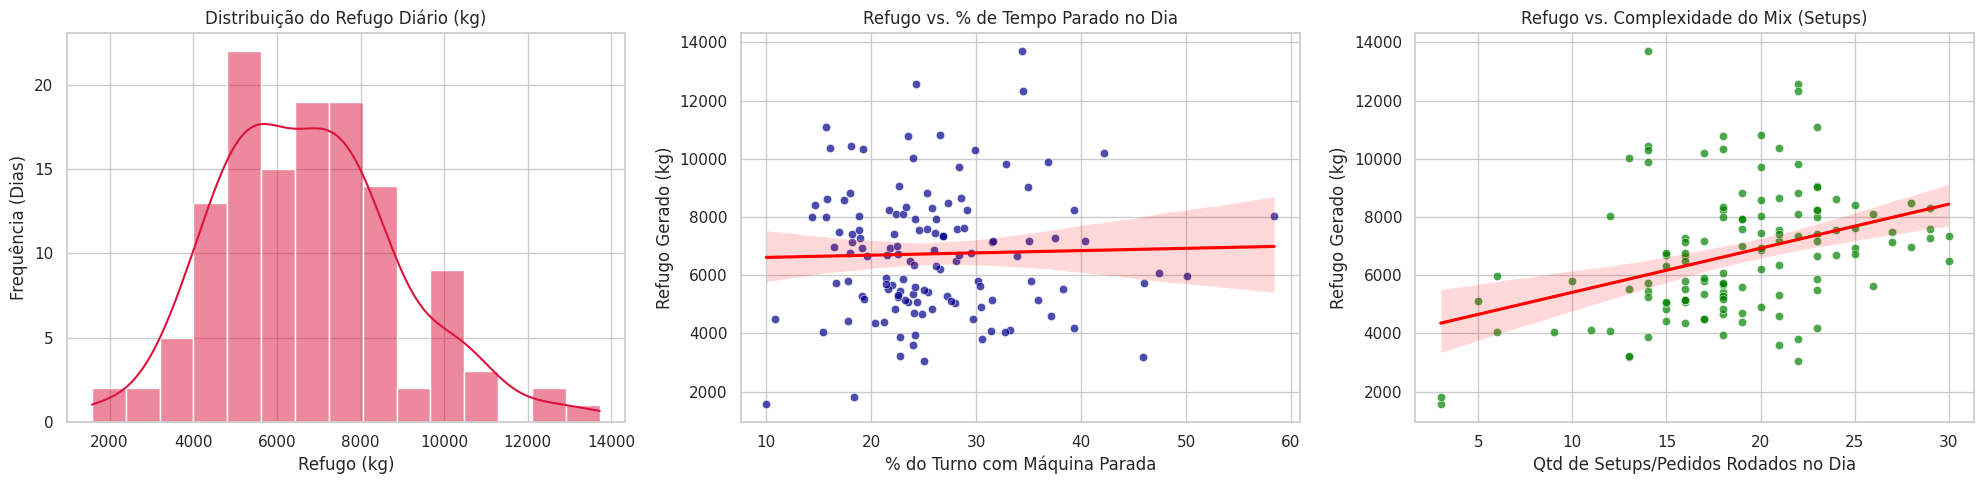




--- MATRIZ DE CORRELAÇÃO ---




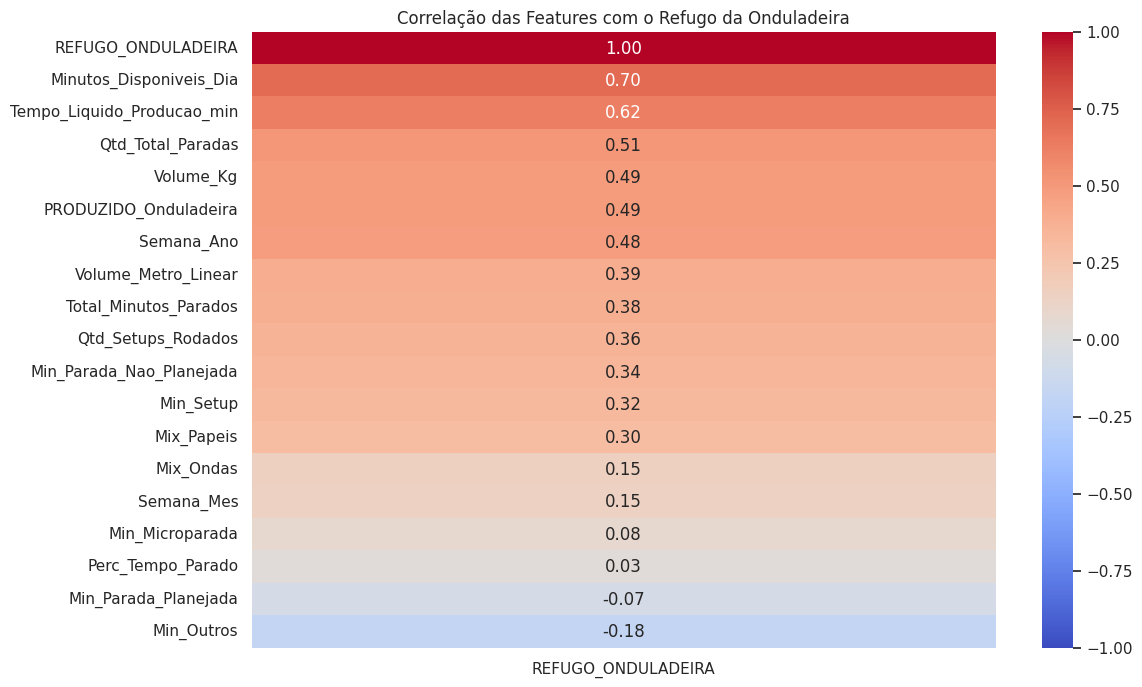

In [12]:
print("\n")
print("--- VISÃO GERAL E ESTATÍSTICAS DESCRITIVAS ---")
print("\n")
df_master.info()
print("\n")

# Estatísticas descritivas das variáveis principais
cols_descritivas = ['REFUGO_ONDULADEIRA', 'Volume_Metro_Linear', 'Perc_Tempo_Parado', 'Qtd_Setups_Rodados']
display(df_master[cols_descritivas].describe().round(2))

print("\n")
print("\n--- ANÁLISE GRÁFICA DO COMPORTAMENTO OPERACIONAL ---")
print("\n")
# Configurando a área de plotagem
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Gráfico 1: Distribuição da Variável-Alvo (Refugo)
sns.histplot(df_master['REFUGO_ONDULADEIRA'], bins=15, kde=True, ax=axes[0], color='crimson')
axes[0].set_title('Distribuição do Refugo Diário (kg)')
axes[0].set_xlabel('Refugo (kg)')
axes[0].set_ylabel('Frequência (Dias)')

# Gráfico 2: Refugo vs. Percentual de Tempo Parado
sns.scatterplot(data=df_master, x='Perc_Tempo_Parado', y='REFUGO_ONDULADEIRA', ax=axes[1], color='darkblue', alpha=0.7)
sns.regplot(data=df_master, x='Perc_Tempo_Parado', y='REFUGO_ONDULADEIRA', ax=axes[1], scatter=False, color='red')
axes[1].set_title('Refugo vs. % de Tempo Parado no Dia')
axes[1].set_xlabel('% do Turno com Máquina Parada')
axes[1].set_ylabel('Refugo Gerado (kg)')

# Gráfico 3: Refugo vs. Quantidade de Setups
sns.scatterplot(data=df_master, x='Qtd_Setups_Rodados', y='REFUGO_ONDULADEIRA', ax=axes[2], color='green', alpha=0.7)
sns.regplot(data=df_master, x='Qtd_Setups_Rodados', y='REFUGO_ONDULADEIRA', ax=axes[2], scatter=False, color='red')
axes[2].set_title('Refugo vs. Complexidade do Mix (Setups)')
axes[2].set_xlabel('Qtd de Setups/Pedidos Rodados no Dia')
axes[2].set_ylabel('Refugo Gerado (kg)')

plt.tight_layout()
plt.show()

print("\n")
print("\n--- MATRIZ DE CORRELAÇÃO ---")
print("\n")
# Selecionando apenas colunas numéricas para a correlação
cols_numericas = df_master.select_dtypes(include=['int64', 'float64']).columns
# Removendo IDs ou anos que não fazem sentido correlacionar
cols_numericas = [c for c in cols_numericas if c not in ['Ano', 'Mês']]

plt.figure(figsize=(12, 8))
correlacao = df_master[cols_numericas].corr()

# Focando a matriz apenas no que importa: a correlação das variáveis com o REFUGO
corr_com_refugo = correlacao[['REFUGO_ONDULADEIRA']].sort_values(by='REFUGO_ONDULADEIRA', ascending=False)
sns.heatmap(corr_com_refugo, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlação das Features com o Refugo da Onduladeira')
plt.show()

### Síntese da Análise Exploratória de Dados (EDA)

Com base no panorama geral da base de dados, consolidamos as seguintes observações  sobre o comportamento físico e operacional da onduladeira:

**Integridade e Estrutura da Base Analítica (ABT)**

O *dataset* final é composto por **128 observações diárias** (representando os dias úteis de operação consolidados) e 20 variáveis. Ausência total de valores nulos ou faltantes (128 *non-null* em todas as colunas), garantindo uma base íntegra para a modelagem preditiva. O dimensionamento restrito da amostra configura um típico cenário de *Small Data* industrial, o que exigirá atenção redobrada na parametrização dos algoritmos para evitar o sobreajuste (*overfitting*).

**Estatísticas Descritivas e Distribuição**

 A média diária de desperdício é de **6.737 Kg**, porém a variância é o fator mais alarmante: há dias de alta estabilidade em que a perda se restringe a 1.576 Kg, contrastando violentamente com anomalias severas que ultrapassam **13.700 Kg** diários. O histograma de distribuição confirma esse comportamento: embora o "miolo" da operação orbite em torno de 5 a 8 toneladas, há uma cauda expressiva à direita evidenciando os dias de colapso operacional.

**Fragmentação de Pedidos e Complexidade do Mix (Setups)**

O gráfico de dispersão que cruza a perda com a Quantidade de Setups comprova o custo do fracionamento de ordens de produção. A linha opera com uma média de quase 19 setups por dia. No entanto, quando o PCP envia um mix pulverizado que exige entre 25 e 30 trocas de pedido no mesmo dia, a linha de tendência linear do refugo é tracionada fortemente para cima. Cada transição implica na quebra da estabilidade mecânica, colagem e tração do papel, gerando apara de transição inevitável.

**Diagnóstico de Linearidade (Mapa de Correlação de Pearson)**

O *Heatmap* hierarquiza o peso das variáveis independentes na geração de perda absoluta. Destacam-se dois perfis de influência direta:
* **A Relação de Escala:** Variáveis ligadas ao tempo de máquina rodando (`Minutos_Disponiveis_Dia` = 0.70; `Tempo_Liquido` = 0.62) e ao output físico (`Volume_Kg` = 0.49). Estatisticamente, uma exposição operacional maior resulta, por proporção direta geométrica, em maior geração de resíduos.
* **O Custo da Frequência vs. Duração:** A correlação indica um *insight* valioso para a gestão industrial. A variável `Qtd_Total_Paradas` possui forte correlação positiva (0.51) com o refugo, enquanto o `Perc_Tempo_Parado` possui correlação praticamente nula (0.03). Isso comprova que não é a *duração estática* da parada que sucateia o papel, mas sim a *frequência de reinícios* (o ciclo "liga-desliga"). Uma parada longa e planejada gera menos refugo do que 15 paradas curtas de instabilidade.

Estas conclusões visuais e matemáticas balizarão o corte de variáveis redundantes na próxima etapa e justificam o teste de algoritmos capazes de lidar com as não-linearidades do chão de fábrica.

In [13]:
# Checando a similaridade entre as duas métricas de volume
correlacao_volumes = df_master[['Volume_Kg', 'PRODUZIDO_Onduladeira']].corr().iloc[0,1]
print(f"Correlação entre Volume_Kg e PRODUZIDO_Onduladeira: {correlacao_volumes:.4f}")

Correlação entre Volume_Kg e PRODUZIDO_Onduladeira: 0.9989


**Tratamento de Multicolinearidade (Remoção da Variável PRODUZIDO_ONDULADEIRA)**

A análise da matriz de correlação revelou uma redundância estrutural crítica entre as variáveis de escala produtiva. Observa-se que a variável `PRODUZIDO_ONDULADEIRA` apresenta exatamente o mesmo grau de correlação linear (0.49) com o refugo que a variável `Volume_Kg`. Operacionalmente, ambas representam a mesma grandeza física. A manutenção de ambas configuraria um cenário de multicolinearidade perfeita, o que distorceria a interpretabilidade dos coeficientes da Regressão Linear e dividiria artificialmente a importância das variáveis (*Feature Importance*) nos algoritmos baseados em árvores. Por este motivo, a variável `PRODUZIDO_ONDULADEIRA` será removida do conjunto de treinamento, elegendo-se `Volume_Kg` como o atributo oficial de escala.

In [14]:
# Removendo a variável redundante para evitar Multicolinearidade
if 'PRODUZIDO_Onduladeira' in df_master.columns:
    df_master = df_master.drop(columns=['PRODUZIDO_Onduladeira'])

df_master.info()
print("\n")
display(df_master.head())

<class 'pandas.core.frame.DataFrame'>
Index: 128 entries, 0 to 146
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Data                        128 non-null    datetime64[ns]
 1   REFUGO_ONDULADEIRA          128 non-null    int64         
 2   Volume_Metro_Linear         128 non-null    float64       
 3   Volume_Kg                   128 non-null    float64       
 4   Qtd_Setups_Rodados          128 non-null    float64       
 5   Mix_Ondas                   128 non-null    float64       
 6   Mix_Papeis                  128 non-null    float64       
 7   Min_Microparada             128 non-null    float64       
 8   Min_Outros                  128 non-null    float64       
 9   Min_Parada_Nao_Planejada    128 non-null    float64       
 10  Min_Parada_Planejada        128 non-null    float64       
 11  Min_Setup                   128 non-null    float64       
 12 

,Data,REFUGO_ONDULADEIRA,Volume_Metro_Linear,Volume_Kg,Qtd_Setups_Rodados,Mix_Ondas,Mix_Papeis,Min_Microparada,Min_Outros,Min_Parada_Nao_Planejada,Min_Parada_Planejada,Min_Setup,Qtd_Total_Paradas,Minutos_Disponiveis_Dia,Semana_Ano,Semana_Mes,Total_Minutos_Parados,Tempo_Liquido_Producao_min,Perc_Tempo_Parado
0,2026-01-05,4091,62317.0,60273.0,12.0,3.0,6.0,0.0,3.0,236.0,0.0,91.0,26.0,1050.0,2,1,330.0,720.0,31.428571
1,2026-01-06,6492,86813.0,99871.0,30.0,3.0,6.0,4.0,10.0,171.0,60.0,160.0,43.0,1440.0,2,1,405.0,1035.0,28.125000
2,2026-01-07,5411,110778.0,105876.0,18.0,2.0,7.0,0.0,0.0,237.0,60.0,69.0,38.0,1440.0,2,1,366.0,1074.0,25.416667
3,2026-01-08,3055,105839.0,107438.0,22.0,3.0,8.0,0.0,20.0,121.0,90.0,130.0,39.0,1440.0,2,2,361.0,1079.0,25.069444
4,2026-01-09,4411,80041.0,85980.0,19.0,3.0,5.0,0.0,7.0,81.0,60.0,78.0,26.0,1065.0,2,2,226.0,839.0,21.220657


### Critério de Seleção das Variáveis para a Análise

A seleção foi pautada pelos sinais estatísticos extraídos da matriz de correlação e pelo conhecimento empírico do processo de ondulação, visando isolar as três dimensões de maior impacto físico e gerencial na geração de perdas:

* **A Dimensão de Escala (`Volume_Kg`):** Selecionada como a principal representante linear do volume produtivo diário, especialmente após o tratamento de multicolinearidade que eliminou variáveis redundantes de saída física. Ela estabelece a linha de base (o quanto se perde simplesmente por processar mais papel).
>
* **A Dimensão de Instabilidade (`Qtd_Total_Paradas`):** Priorizada em relação às variáveis de tempo absoluto de máquina parada. O fato de parar a máquina é o gera refugo e o tempo que a máquina fica parada não tem a mesma influência.
>
* **A Dimensão Sazonal e Gerencial (`Semana_Mes`):** Selecionada para investigação categórica (via diagrama de caixa) a fim de validar uma forte hipótese de negócio: a deterioração da estabilidade operacional sob a pressão do sequenciamento acelerado de pedidos para cumprimento de metas de faturamento no encerramento do ciclo mensal.

Esta filtragem estratégica evita a poluição visual ("*chart junk*") e garante que o desenvolvimento seja norteado pelo realmente oferece oportunidade de intervenção e otimização por parte da gestão industrial.

## Análise das Features Selecionadas X Target (Refugo(Kg))



--- INVESTIGAÇÃO VISUAL DAS PRINCIPAIS RELAÇÕES ---




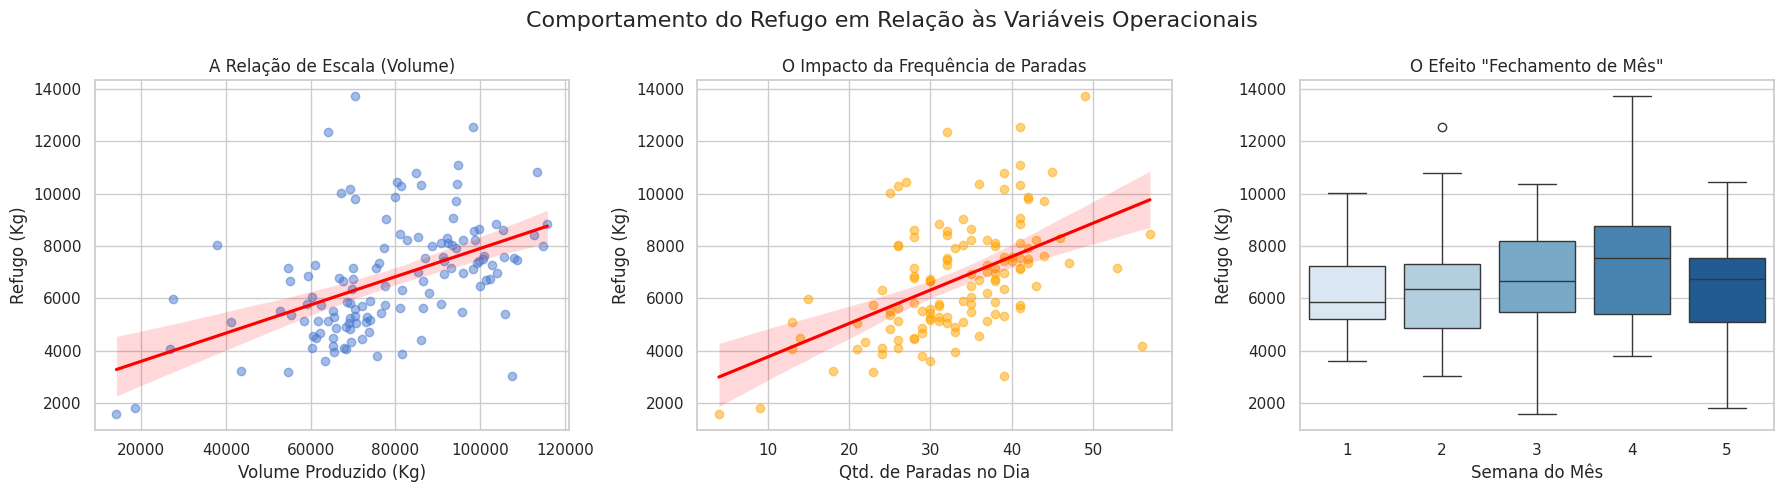

In [15]:
print("\n")
print("--- INVESTIGAÇÃO VISUAL DAS PRINCIPAIS RELAÇÕES ---")
print("\n")

# Criando um painel com 3 gráficos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comportamento do Refugo em Relação às Variáveis Operacionais', fontsize=16)

# Gráfico 1: Refugo vs Volume Produzido (Dispersão com Linha de Tendência)
sns.regplot(ax=axes[0], data=df_master, x='Volume_Kg', y='REFUGO_ONDULADEIRA',
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[0].set_title('A Relação de Escala (Volume)')
axes[0].set_xlabel('Volume Produzido (Kg)')
axes[0].set_ylabel('Refugo (Kg)')

# Gráfico 2: Refugo vs Quantidade de Paradas (Dispersão)
sns.regplot(ax=axes[1], data=df_master, x='Qtd_Total_Paradas', y='REFUGO_ONDULADEIRA',
            scatter_kws={'alpha':0.5, 'color':'orange'}, line_kws={'color':'red'})
axes[1].set_title('O Impacto da Frequência de Paradas')
axes[1].set_xlabel('Qtd. de Paradas no Dia')
axes[1].set_ylabel('Refugo (Kg)')

# Gráfico 3: Refugo vs Semana do Mês (Boxplot para ver a distribuição)
sns.boxplot(ax=axes[2], data=df_master, x='Semana_Mes', y='REFUGO_ONDULADEIRA', palette='Blues')
axes[2].set_title('O Efeito "Fechamento de Mês"')
axes[2].set_xlabel('Semana do Mês')
axes[2].set_ylabel('Refugo (Kg)')

plt.tight_layout()
plt.show()

### Interpretação da Análise

A análise visual das variáveis independentes em relação à variável-alvo (Refugo) valida as premissas matemáticas levantadas pelos modelos lineares e pela matriz de correlação, traduzindo os coeficientes em comportamentos físicos do processo produtivo:

**1. A Relação de Escala (Volume Produzido vs. Refugo)**

O primeiro gráfico de dispersão evidencia uma relação linear positiva consistente, corroborando o coeficiente de correlação identificado anteriormente (0.49). Essa dinâmica reflete a natureza inerente do processo de ondulação: maiores volumes absolutos de papel processado (exposição operacional) resultam, estatística e naturalmente, em uma maior geração de perdas na mesma escala geométrica.

**2. O Impacto da Instabilidade (Frequência de Paradas)**

A segunda visualização revela o efeito nocivo da instabilidade térmica e mecânica na máquina onduladeira. Observa-se que em dias com menor frequência de interrupções (entre 10 e 20 paradas), a variância do refugo mantém-se contida e previsível. No entanto, ao ultrapassar o limiar de 30 ocorrências, a dispersão (heterocedasticidade) aumenta acentuadamente e os volumes de perda atingem picos críticos (superiores a 12 toneladas). Isso comprova que os sucessivos ciclos de reinício da máquina ("liga-desliga") deterioram o rendimento do processo de forma muito mais agressiva do que o tempo total de paradas longas.

**3. Sazonalidade Gerencial (O Efeito "Fechamento de Mês")**

O diagrama de caixa (boxplot) fornece a evidência estatística preliminar de um gargalo de natureza sistêmica. Nota-se um deslocamento progressivo e ascendente da mediana do refugo ao longo das semanas do mês. A distribuição de perdas na quarta e quinta semanas é visivelmente superior em relação à primeira semana. Esta anomalia visual levanta a forte hipótese de que a variação no ritmo de produção e a pressão operacional para bater metas de faturamento geram desperdício adicional de matéria-prima.

>Com base na nítida relação linear geométrica observada no Gráfico 1, a Regressão Linear Múltipla será utilizada como o modelo baseline (linha de base) desta etapa preditiva. Além de lidar de forma natural com proporções diretas (Volume vs. Perda), este algoritmo oferece altíssima interpretabilidade: seus coeficientes nos permitirão traduzir o impacto de cada evento (como uma parada adicional ou a transição para a Semana 4) diretamente em quilos de refugo.

## MODELAGEM PREDITIVA

In [16]:
# Separando Variáveis Previsoras (X) e Variável-Alvo (y)
X = df_master.drop(columns=['Data', 'REFUGO_ONDULADEIRA'])
y = df_master['REFUGO_ONDULADEIRA']

# Separando 80% para treino e 20% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Treinamento: {X_train.shape[0]} dias de operação.")
print(f"Teste: {X_test.shape[0]} dias de operação.\n")

print("--- TREINAMENTO E AVALIAÇÃO DOS MODELOS ---")

# Dicionário com os QUATRO competidores
modelos = {
    "1. Baseline (Regressão Linear)": LinearRegression(),
    "2. Random Forest": RandomForestRegressor(random_state=42, n_estimators=100, max_depth=5),
    "3. XGBoost": XGBRegressor(random_state=42, n_estimators=100, max_depth=3, learning_rate=0.1),
    "4. LightGBM": LGBMRegressor(random_state=42, n_estimators=100, max_depth=3, learning_rate=0.1, verbose=-1)
}

# Loop para treinar e avaliar cada um
for nome, modelo in modelos.items():
    # Treino
    modelo.fit(X_train, y_train)

    # Previsões na base de Teste
    previsoes = modelo.predict(X_test)

    # Avaliação
    mae = mean_absolute_error(y_test, previsoes)
    rmse = np.sqrt(mean_squared_error(y_test, previsoes))
    mape = mean_absolute_percentage_error(y_test, previsoes) * 100
    r2 = r2_score(y_test, previsoes)

    print(f"{nome}")
    print(f" -> MAE (Média de Erro):      {mae:.2f} Kg")
    print(f" -> RMSE (Tolerância a Pico): {rmse:.2f} Kg")
    print(f" -> MAPE (Erro Percentual):   {mape:.2f} %")
    print(f" -> R² (Poder de Explicação): {r2:.4f}\n")

Treinamento: 102 dias de operação.
Teste: 26 dias de operação.

--- TREINAMENTO E AVALIAÇÃO DOS MODELOS ---
1. Baseline (Regressão Linear)
 -> MAE (Média de Erro):      998.14 Kg
 -> RMSE (Tolerância a Pico): 1250.48 Kg
 -> MAPE (Erro Percentual):   17.94 %
 -> R² (Poder de Explicação): 0.6676

2. Random Forest
 -> MAE (Média de Erro):      1041.51 Kg
 -> RMSE (Tolerância a Pico): 1313.03 Kg
 -> MAPE (Erro Percentual):   18.12 %
 -> R² (Poder de Explicação): 0.6335

3. XGBoost
 -> MAE (Média de Erro):      1232.01 Kg
 -> RMSE (Tolerância a Pico): 1589.14 Kg
 -> MAPE (Erro Percentual):   22.95 %
 -> R² (Poder de Explicação): 0.4632

4. LightGBM
 -> MAE (Média de Erro):      1092.90 Kg
 -> RMSE (Tolerância a Pico): 1494.77 Kg
 -> MAPE (Erro Percentual):   20.97 %
 -> R² (Poder de Explicação): 0.5251



### Teste Inicial - Avaliação

Num cenário inicial sem uma análise exploratória mais profunda, feature selection e cross validation, os melhores resultados vieram do modelo Baseline (Regressão Linear).

*   Menor Erro Médio (996 Kg) - MAE
*   Menor Tolerância a Picos (1252 Kg) - RMSE
*   Menor Erro Percentual (17,91%) - MAPE
*   Maior Poder de Explicação (66,64%) - R²

> Agora, vou entender o peso de cada variável no refugo: O quanto a ocorrência de uma das variáveis impacta no refugo da onduladeira em quilos (Kg).
>
> Para isso vou analisar os coeficiêntes da equação de regressão descoberta pelo modelo partindo do princípio que a interpretação matemática de um coeficiente de regressão é sempre: "Qual é a variação esperada em $y$ para cada 1 unidade adicional de $X$?"



--- PESO MATEMÁTICO DE CADA VARIÁVEL NO REFUGO ---



,Variavel,Impacto_em_Kg
13,Semana_Mes,279.96
10,Qtd_Total_Paradas,80.83
12,Semana_Ano,42.62
4,Mix_Papeis,29.53
9,Min_Setup,7.86
15,Tempo_Liquido_Producao_min,7.70
7,Min_Parada_Nao_Planejada,5.26
11,Minutos_Disponiveis_Dia,2.52
16,Perc_Tempo_Parado,1.51
1,Volume_Kg,0.03


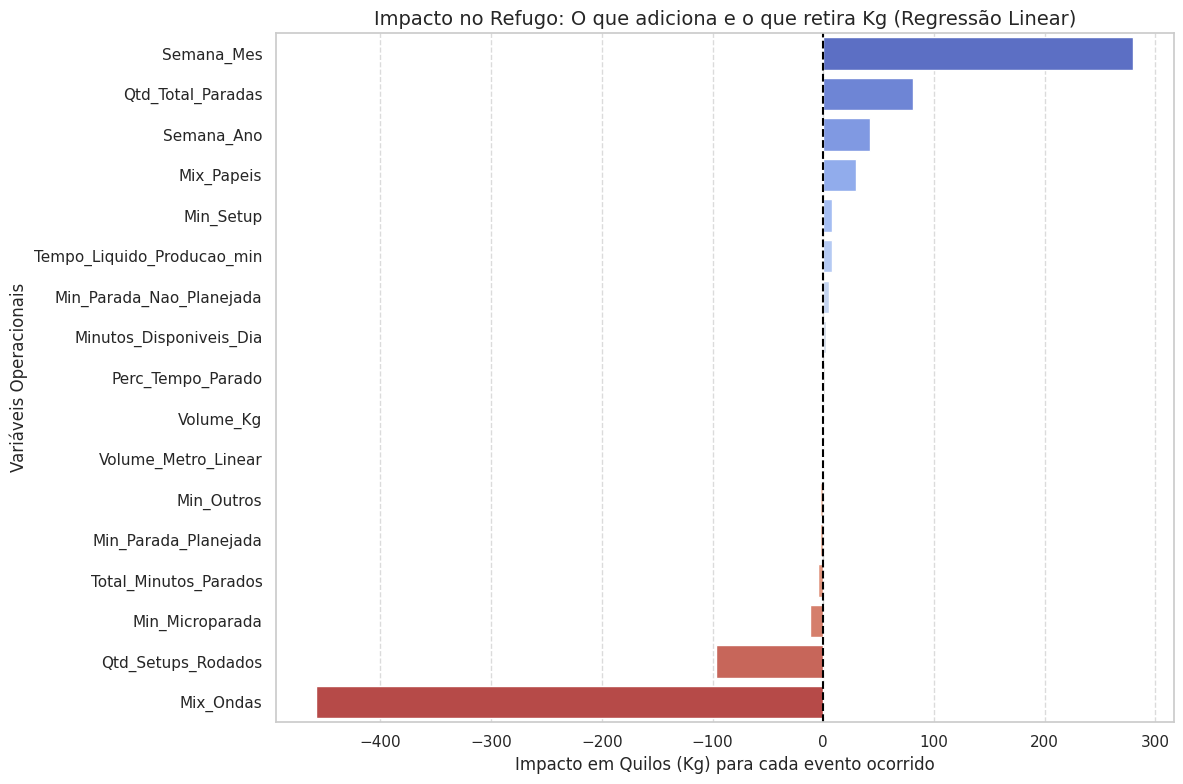

In [17]:
modelo_vencedor = modelos["1. Baseline (Regressão Linear)"]

# Extraindo os coeficientes (Quantos Kg cada variável adiciona/retira)
df_coeficientes = pd.DataFrame({
    'Variavel': X_train.columns,
    'Impacto_em_Kg': modelo_vencedor.coef_
})

# Ordenando pelo maior impacto positivo para o maior impacto negativo
df_coeficientes = df_coeficientes.sort_values(by='Impacto_em_Kg', ascending=False)

print("\n")
print("--- PESO MATEMÁTICO DE CADA VARIÁVEL NO REFUGO ---\n")
display(df_coeficientes.round(2))

# Plotando o resultado
plt.figure(figsize=(12, 8))
sns.barplot(x='Impacto_em_Kg', y='Variavel', data=df_coeficientes, palette='coolwarm')
plt.title('Impacto no Refugo: O que adiciona e o que retira Kg (Regressão Linear)', fontsize=14)
plt.xlabel('Impacto em Quilos (Kg) para cada evento ocorrido')
plt.ylabel('Variáveis Operacionais')
plt.axvline(x=0, color='black', linestyle='--') # Linha do zero
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

As duas variáveis que lideram de forma absoluta o aumento do refugo na sua fábrica são:

* Semana_Mes - (+279.96 Kg)
* Qtd_Total_Paradas - (+80.83 Kg)

>**O "Efeito Fechamento de Mês"**
>
>O algoritmo percebeu que a cada semana que avançamos dentro do mês, o refugo base sobe em quase 280 quilos.
>
>Ou seja, rodar a máquina na Semana 4 gera quase 840 Kg a mais de perda do que na Semana 1, independentemente do volume.
>
>Isso comprova matematicamente que o estresse operacional para bater a meta de faturamento no fim do mês estão gerando um custo invisível altíssimo em desperdício de papel.

>**O Problema do "Liga-Desliga" (Frequência vs. Duração)**
>
>A quantidade de paradas (Qtd_Total_Paradas) adiciona 80 quilos por evento.
>
>O modelo provou que o que gera refugo na onduladeira não é a máquina ficar parada por 2 horas consertando uma peça. O que destrói a margem é o "liga-desliga". Toda vez que a máquina para abruptamente e precisa reiniciar, perdem-se dezenas de metros de papel apenas para reestabilizar a temperatura das chapas e a tração da ponte. Evitar micro interrupções é mais urgente do que acelerar grandes manutenções.

## FEATURE SELECTION E CROSS-VALIDATION

### Seleção de Variáveis (Feature Selection) e Validação Cruzada (K-Fold Cross Validation)

A etapa de Seleção de Variáveis (*Feature Selection*) foi conduzida de forma integrada à Validação Cruzada (*5-Fold Cross-Validation*) com o objetivo de otimizar a capacidade de generalização dos algoritmos preditivos e mitigar o risco de sobreajuste (*overfitting*), e assim aprender o padrão real do processo produtivo.

O critério de retenção e descarte de atributos baseou-se na intersecção entre o diagnóstico das análises e o conhecimento empírico do processo de ondulação. Foram eliminadas variáveis que apresentavam alta multicolinearidade e atributos de baixa correlação que apenas inseriam dispersão nas equações.
>O escopo de entrada do modelo foi intencionalmente afunilado para as dimensões de maior impacto físico e gerencial: escala de produção (Volume), fragmentação do sequenciamento (Setups), instabilidade operacional (Quantidade de Paradas) e sazonalidade de faturamento (Semana do Mês).

In [18]:
print("\n")
print("--- FEATURE SELECTION (ENXUGANDO O MODELO) ---")

# Selecionando apenas as variáveis de alto impacto baseadas nos coeficientes anteriores
# Removi ruídos e redundâncias (ex: Metro Linear, Min_Outros, Perc_Tempo)
features_de_elite = [
    'Volume_Kg',
    'Semana_Mes',
    'Semana_Ano',
    'Qtd_Total_Paradas',
    'Min_Parada_Nao_Planejada',
    'Min_Setup',
    'Qtd_Setups_Rodados',
    'Mix_Papeis',
    'Mix_Ondas',
    'Tempo_Liquido_Producao_min'
]

X_elite = df_master[features_de_elite]
y_alvo = df_master['REFUGO_ONDULADEIRA']

print(f"Cairam de {X.shape[1]} para {X_elite.shape[1]} variáveis selecionadas.\n")

print("--- CROSS-VALIDATION (5-FOLD) ---")

# Criando o KFold (5 Folds)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Dicionário informando ao Scikit-Learn quais métricas queremos em cada rodada
metricas_cv = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'mape': 'neg_mean_absolute_percentage_error',
    'r2': 'r2'
}

# Reiniciando os 4 competidores para a prova final
modelos_finais = {
    "Regressão Linear (Baseline)": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100, max_depth=5),
    "XGBoost": XGBRegressor(random_state=42, n_estimators=100, max_depth=3, learning_rate=0.1),
    "LightGBM": LGBMRegressor(random_state=42, n_estimators=100, max_depth=3, learning_rate=0.1, verbose=-1)
}

print(f"Treinando 4 modelos, 5 vezes cada (Total de 20 treinamentos).\n")

resultados = []

# ==============================================================================
# --- EXECUÇÃO ---
# ==============================================================================
for nome, modelo in modelos_finais.items():

    # A função cross_validate vai treinar e testar nos 5 folds
    cv_results = cross_validate(
        modelo, X_elite, y_alvo,
        cv=kfold,
        scoring=metricas_cv
    )

    # Extraindo as médias das 5 provas e invertendo o sinal das métricas de erro
    mae_medio = np.mean(cv_results['test_mae']) * -1
    rmse_medio = np.mean(cv_results['test_rmse']) * -1
    mape_medio = np.mean(cv_results['test_mape']) * -1 * 100 # Multiplicando por 100 para formato %
    r2_medio = np.mean(cv_results['test_r2'])

    # Guardando o resultado do modelo para exibir em um DataFrame do Pandas
    resultados.append({
        'Modelo': nome,
        'MAE (Kg)': mae_medio,
        'RMSE (Kg)': rmse_medio,
        'MAPE (%)': mape_medio,
        'R²': r2_medio
    })

# ==============================================================================
# --- BOLETIM FINAL ---
# ==============================================================================

df_ranking = pd.DataFrame(resultados)

# Ordenando pelo menor MAE (Erro Médio)
df_ranking = df_ranking.sort_values(by='MAE (Kg)', ascending=True).reset_index(drop=True)

print("RANKING DEFINITIVO DOS MODELOS (Média de 5 Folds + Feature Selection)")
print("======================================================================================")
display(df_ranking.round(2))



--- FEATURE SELECTION (ENXUGANDO O MODELO) ---
Cairam de 17 para 10 variáveis selecionadas.

--- CROSS-VALIDATION (5-FOLD) ---
Treinando 4 modelos, 5 vezes cada (Total de 20 treinamentos).

RANKING DEFINITIVO DOS MODELOS (Média de 5 Folds + Feature Selection)


,Modelo,MAE (Kg),RMSE (Kg),MAPE (%),R²
0,Random Forest,1070.77,1438.44,17.73,0.54
1,Regressão Linear (Baseline),1086.65,1428.55,18.00,0.54
2,XGBoost,1145.80,1542.83,19.26,0.47
3,LightGBM,1168.87,1508.23,20.17,0.50


## OTIMIZAÇÃO DE HIPERPARÂMETROS (TUNING)

In [19]:
print("\n")
print("--- INICIANDO A BUSCA DOS MELHORES HIPERPARÂMETROS ---")

# Definindo a grade (grid) de testes para o Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],          # Quantidade de árvores floresta
    'max_depth': [3, 5, 8, 12, None],        # Profundidade máxima (complexidade de regras)
    'min_samples_split': [2, 5, 10],         # Mínimo de amostras exigidas para dividir um nó
    'min_samples_leaf': [1, 2, 4]            # Mínimo de amostras permitidas na folha final (evita overfitting)
}

# Configurando o GridSearchCV
# Ele vai usar o kfold (5 dobras) e o MAE negativo como bússola
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=kfold,
    scoring='neg_mean_absolute_error',
    n_jobs=-1, # Usa todos os núcleos do seu processador para ir mais rápido
    verbose=1  # Mostra o progresso na tela
)

# Executando o treinamento exaustivo
print("Testando todas as combinações matemáticas.\n")
grid_search.fit(X_elite, y_alvo)

# Extraindo o vencedor
rf_otimizado = grid_search.best_estimator_
mae_otimizado = grid_search.best_score_ * -1

print("RESULTADO DA OTIMIZAÇÃO (GRID SEARCH)")
print("==================================================")
print("A melhor regulagem encontrada para a onduladeira foi:")
for param, valor in grid_search.best_params_.items():
    print(f" -> {param}: {valor}")
print("==================================================")
print(f"MAE Médio (Cross-Validation do Modelo Otimizado): {mae_otimizado:.2f} Kg")



--- INICIANDO A BUSCA DOS MELHORES HIPERPARÂMETROS ---
Testando todas as combinações matemáticas.

Fitting 5 folds for each of 135 candidates, totalling 675 fits
RESULTADO DA OTIMIZAÇÃO (GRID SEARCH)
A melhor regulagem encontrada para a onduladeira foi:
 -> max_depth: 5
 -> min_samples_leaf: 1
 -> min_samples_split: 10
 -> n_estimators: 50
MAE Médio (Cross-Validation do Modelo Otimizado): 1047.91 Kg


## AVALIANDO O MODELO OTIMIZADO EM TODAS AS MÉTRICAS

In [20]:
# Passando o modelo vencedor (rf_otimizado) num K-Fold
cv_campeao = cross_validate(
    rf_otimizado, X_elite, y_alvo,
    cv=kfold,
    scoring=metricas_cv
)

# Extraindo as médias e ajustando os sinais
mae_final = np.mean(cv_campeao['test_mae']) * -1
rmse_final = np.mean(cv_campeao['test_rmse']) * -1
mape_final = np.mean(cv_campeao['test_mape']) * -1 * 100
r2_final = np.mean(cv_campeao['test_r2'])

print("BOLETIM DEFINITIVO (RANDOM FOREST OTIMIZADO)")
print("==================================================")
print(f" -> MAE (Erro Médio):      {mae_final:.2f} Kg")
print(f" -> RMSE (Tolerância):     {rmse_final:.2f} Kg")
print(f" -> MAPE (Erro Percentual):{mape_final:.2f} %")
print(f" -> R² (Explicação):       {r2_final:.4f}")
print("==================================================")

BOLETIM DEFINITIVO (RANDOM FOREST OTIMIZADO)
 -> MAE (Erro Médio):      1047.91 Kg
 -> RMSE (Tolerância):     1406.63 Kg
 -> MAPE (Erro Percentual):17.84 %
 -> R² (Explicação):       0.5622


### Justificativa e Resultados da Otimização de Hiperparâmetros

Após a avaliação inicial cruzada e a etapa de *Feature Selection*, o Random Forest consolidou-se como o algoritmo mais promissor. Para refinar sua capacidade preditiva e mitigar o risco de over e underfitting foi aplicada a estratégia de Busca em Grade exaustiva (*GridSearchCV*) integrada à Validação Cruzada (*5-Fold Cross-Validation*).

* **Quais hiperparâmetros foram ajustados:** Foram submetidos à grade de testes a profundidade máxima das árvores (`max_depth`), o número mínimo de amostras para dividir um nó (`min_samples_split`), o número mínimo de amostras na folha final (`min_samples_leaf`) e a quantidade total de árvores (`n_estimators`).
* **Por que esses hiperparâmetros foram escolhidos:** O objetivo técnico destas escolhas foi mitigar o risco de *overfitting* inerente a bases com volumetria restrita (*Small Data*). Restringir a profundidade máxima e exigir um número mínimo de amostras para divisão (ex: 10 dias de operação) impede que o modelo crie ramificações altamente específicas para "decorar" dias atípicos de refugo extremo do conjunto de treino.
* **Qual critério foi usado para selecionar a melhor configuração:** O parâmetro de otimização (bússola) escolhido foi o Erro Médio Absoluto Negativo (`neg_mean_absolute_error`).
>500 Kg de perda de papel custam exatamente o mesmo valor nos dois dias. Otimizar pelo MAE garante que o algoritmo foque em acertar o peso físico, independentemente da escala do dia.
>
O algoritmo foi instruído a selecionar a combinação de hiperparâmetros que retornasse o menor desvio médio absoluto, em quilos, ao longo das 5 rodadas de testes da validação cruzada.

* **Houve melhora em relação ao modelo sem ajuste?** Sim, a otimização resultou em um modelo consideravelmente mais eficiente (`max_depth=5`, `n_estimators=50`, `min_samples_split=10`, `min_samples_leaf=1`).
* O Erro Médio Absoluto (MAE) foi reduzido de 1.070,77 Kg para 1.047,91 Kg.
* O Erro Absoluto Percentual Médio (MAPE) apresentou uma variação marginal, passando de 17,73% para 17,84%; este levíssimo incremento é metodologicamente justificado, visto que o otimizador penalizou o volume absoluto (MAE) em detrimento da métrica relativa, abrindo mão de frações percentuais para ganhar estabilidade.
>A melhoria mais expressiva, contudo, deu-se na tolerância a picos anômalos: ao travar a complexidade das árvores;
>
>* A Raiz do Erro Quadrático Médio (RMSE) caiu de 1.438,44 Kg para 1.406,63 Kg, garantindo o maior poder de explicação (R²) de todo o projeto: 56,22%.

### Avaliação Consolidada dos Resultados

A avaliação dos algoritmos preditivos foi conduzida sob rigorosos critérios estatísticos, com foco na aplicabilidade industrial do modelo para o chão de fábrica. Abaixo, detalhamos a performance, as escolhas metodológicas e os diagnósticos do modelo campeão:

**Justificativa das Métricas Escolhidas**

Tratando-se de um problema de regressão focado em controle de desperdício (custo de manufatura), as seguintes métricas foram selecionadas:
* **MAE (Erro Médio Absoluto):** Métrica primária de otimização. Como o desperdício é tarifado pelo peso físico (Kg) e não por proporção, o MAE penaliza os erros de forma linear, refletindo o custo financeiro real diário da operação (mediana).
* **RMSE (Raiz do Erro Quadrático Médio):** Métrica secundária crítica. Ao penalizar erros de forma quadrática, o RMSE avalia a tolerância do modelo aos "dias de caos" (outliers gerados por excesso de paradas). Modelos com RMSE muito superior ao MAE indicam vulnerabilidade a anomalias.
* **MAPE (Erro Percentual Absoluto Médio):** Utilizado para contextualizar a margem de erro para a diretoria, traduzindo o desvio em quilos para uma proporção do volume total processado no dia.
* **R² (Coeficiente de Determinação):** Utilizado para quantificar o percentual da variância do refugo que é explicado exclusivamente pelas variáveis operacionais inseridas no modelo.

**Avaliação em Dados Não Vistos e Comparação de Modelos**

Para garantir a robustez na avaliação com dados não vistos, abdicou-se da divisão simples (*Holdout*) em favor da **Validação Cruzada (5-Fold Cross-Validation)**. O conjunto de dados foi rotacionado 5 vezes, testando os algoritmos exclusivamente em fatias cegas do histórico.
Na comparação dos *baselines*, a **Regressão Linear** mostrou-se incrivelmente sólida (MAE de 1.086 Kg) devido à forte linearidade entre produção e perda. Contudo, ao isolar apenas as variáveis de alta relevância (*Feature Selection*), o **Random Forest** superou a regressão matemática (MAE de 1.070 Kg), capturando melhor as relações não-lineares, como o peso exponencial da frequência de interrupções da máquina.

**Diagnóstico de Overfitting e Underfitting**

O diagnóstico inicial revelou sinais de **Overfitting** por parte dos algoritmos mais profundos (*XGBoost* e *LightGBM*). Em um contexto de *Small Data* (apenas 128 dias úteis), o XGBoost "decorou" os ruídos da base de treino e apresentou a pior performance na validação cruzada (RMSE de 1.542 Kg).
A solução adotada para mitigar este *overfitting* foi a tunagem de hiperparâmetros do Random Forest (*GridSearchCV*). Ao limitar a profundidade das árvores (`max_depth=5`) e exigir um mínimo de 10 amostras para criar divisões lógicas (`min_samples_split=10`), impediu-se que o algoritmo criasse regras superespecíficas para dias isolados.
>O resultado foi uma queda expressiva no RMSE do Random Forest otimizado (de 1.438 Kg para 1.406 Kg), provando a sua capacidade superior de generalização.

Por outro lado, o risco oposto de **Underfitting** (subajuste) foi ativamente mitigado em duas frentes. Primeiro, pela própria transição do *baseline* (Regressão Linear) para o Random Forest, permitindo que o modelo capturasse as não-linearidades inerentes à instabilidade térmica/mecânica da onduladeira (o aumento exponencial do refugo em dias com mais de 30 paradas). Segundo, o limite estabelecido no *GridSearch* garantiu que o modelo mantivesse complexidade estrutural suficiente para aprender as dinâmicas operacionais complexas, evitando que o algoritmo colapsasse em um modelo ingênuo que previsse apenas a média histórica.

**Limitações e Próximos Passos (Síntese)**

Como detalhado em seguida na conclusão geral do projeto, os resultados esbarram em duas grandes limitações: a profundidade histórica do *dataset* (curta janela de treino) e a ausência de dados de telemetria IoT (velocidade da máquina, temperatura das chapas, umidade do papel). Futuras melhorias devem focar em estender a base histórica para capturar sazonalidades anuais e integrar o modelo otimizado a um *dashboard* de simulação de PCP, permitindo intervenções proativas antes do início dos turnos de produção.

# Conclusão e Próximos Passos

Este MVP consolidou a aplicação de técnicas de Ciência de Dados para resolver um problema clássico de ineficiência na indústria de embalagens, transformando apontamentos rotineiros em inteligência operacional. Abaixo, detalhamos os achados e a jornada do projeto:

**1. O Problema Abordado**

A indústria de papelão ondulado sofre com altos custos invisíveis gerados pela perda de material. O objetivo deste trabalho foi sair de uma análise retroativa e reativa para uma abordagem preditiva, utilizando Machine Learning para prever o volume diário de refugo da onduladeira com base no planejamento de produção e nos eventos do chão de fábrica.

**2. O Dataset Utilizado**

O projeto utilizou uma extração de dados do histórico de apontamentos da máquina. Foram cruzadas 6 tabelas relacionais (Fatos: Produção, Paradas, Tempo de Turno e Refugo; Dimensões: Causas e Calendário). Após o cruzamento e limpeza, a Base Analítica (ABT) consolidou o histórico em 128 dias úteis de operação.

**3. Principais Tratamentos Realizados**

A preparação da base exigiu forte *Feature Engineering*. Os principais tratamentos incluíram:
* A remoção de linhas nulas estruturais oriundas da exportação.
* O pivoteamento das causas de parada (transformando linhas de eventos em colunas de soma de minutos por categoria).
* A criação de métricas de eficiência (Tempo Líquido e % de Tempo Parado).
* A eliminação de multicolinearidade perfeita (descarte da variável `PRODUZIDO_Onduladeira` em favor do `Volume_Kg`).
* *Feature Selection* baseada na extração de coeficientes, enxugando a base para reter apenas variáveis operacionais de alto impacto e mitigar a maldição da dimensionalidade.

**4. Modelos Avaliados**

Foram submetidos a um torneio preditivo quatro algoritmos de naturezas distintas: Regressão Linear (como Baseline oficial), Random Forest, XGBoost e LightGBM. Todos foram avaliados utilizando a técnica de Validação Cruzada (*5-Fold Cross-Validation*) para garantir que a performance não fosse enviesada por uma divisão aleatória de dados (*holdout*).

**5. O Melhor Resultado Encontrado**

O algoritmo campeão definitivo foi o **Random Forest**. Após passar por um processo exaustivo de otimização de hiperparâmetros via *GridSearchCV* (limitando a profundidade das árvores e ajustando o critério de *split*), o modelo foi submetido a uma validação cruzada rigorosa, entregando os seguintes resultados consolidados:
* **MAE (Erro Médio Absoluto):** 1.047,91 Kg
* **RMSE (Raiz do Erro Quadrático Médio):** 1.406,63 Kg
* **MAPE (Erro Absoluto Percentual):** 17,84%
* **R² (Poder de Explicação):** 56,22%

**6. Justificativa para a Escolha**

Inicialmente, a Regressão Linear apresentou-se como um *baseline* forte e robusto. No entanto, após a aplicação de *Feature Selection* (remoção de variáveis ruidosas) e *Tuning* de hiperparâmetros, o Random Forest superou o modelo linear em todas as frentes. A otimização com hiperparâmetros mais conservadores (`max_depth=5`, `min_samples_split=10`) foi o ponto de virada: ela eliminou o *overfitting* inerente aos modelos de árvore em cenários de *Small Data*, fazendo com que o RMSE (métrica sensível a erros extremos) despencasse. O modelo provou ser superior na captura de não-linearidades operacionais — como o peso brutal que a *frequência* de quebras da máquina e o "Efeito Fechamento de Mês" exercem sobre a geração de perdas.

**7. Limitações do MVP**
* **Small Data:** O modelo atual aprendeu com um recorte de pouco mais de 100 dias úteis, o que limita sua capacidade de reconhecer sazonalidades anuais longas.
* **Ausência de Telemetria:** O modelo baseia-se exclusivamente em dados tabulares de apontamento humano (ERP/PCP). Não há captura de variáveis contínuas cruciais da onduladeira, como temperatura das chapas quentes, tração da ponte, velocidade da máquina (m/min) ou umidade do papel no momento da quebra.
* **Granularidade:** A previsão foi feita no nível "Diário", o que não permite prever o refugo exato de uma Ordem de Produção (OP) específica.

**8. Possíveis Próximos Passos**
* **Ampliação do Histórico:** Alimentar o modelo com no mínimo 12 a 24 meses de dados para estabilizar ainda mais o aprendizado.
* **Integração IoT (Internet das Coisas):** Acoplar dados de sensores reais da máquina à tabela de produção para que o algoritmo entenda a física da quebra, não apenas a matemática do volume.
* **Simulador PCP (Interface):** Fazer o *deploy* deste modelo em uma aplicação web (Streamlit, por exemplo) para que os analistas de PCP possam simular a grade de produção do dia seguinte. O usuário inseriria o volume esperado e a quantidade de setups, e o modelo retornaria a previsão de perda, ajudando a otimizar a programação de pedidos antes mesmo do papel entrar na máquina.